<a href="https://colab.research.google.com/github/shankarvarun01-hash/cadent-debt-sim/blob/main/debt_interest_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
REPO_URL = "https://github.com/shankarvarun01-hash/cadent-debt-sim.git"
!git clone $REPO_URL

Cloning into 'cadent-debt-sim'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 20 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 7.15 KiB | 7.15 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [12]:
%cd cadent-debt-sim
!ls
!ls src

/content/cadent-debt-sim/cadent-debt-sim
README.md  src	Untitled1.ipynb
charts.py  debt_data.py  metrics.py  placeholder.txt  simulation.py


In [13]:
from google.colab import files
uploaded = files.upload()

Saving simulation_scenarios.csv to simulation_scenarios.csv


In [14]:
import os
os.listdir()

['Untitled1.ipynb', 'simulation_scenarios.csv', '.git', 'README.md', 'src']

In [16]:
import sys
import os

sys.path.append(os.getcwd())

In [17]:
from src.debt_data import load_debt_table, debt_summary
from src.simulation import prepare_rate_matrix, simulate_runoff, simulate_full_refinancing
from src.metrics import summarise_distribution, cumulative_summary, riskiest_years
from src.charts import plot_maturity_wall, plot_runoff_outstanding, plot_interest_regimes

print("Imports successful")

Imports successful


In [19]:
import pandas as pd
import numpy as np
from pathlib import Path

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

START_YEAR = 2025
HORIZON_YEARS = 30
SCENARIO_PATH = "simulation_scenarios.csv"

In [20]:
debt = load_debt_table()
summary = debt_summary(debt)

debt.head(), summary

(                instrument  notional_gbp_m       rate_type  coupon_or_spread  \
 0  Related party loan OD 1             255   floating_base           0.01000   
 1  Related party loan OD 2              64   floating_base           0.03507   
 2  Related party loan OD 3               3   floating_base           0.01000   
 3       Related party loan             700  floating_sonia           0.00750   
 4       Related party loan             500           fixed           0.04106   
 
   maturity_date           rate_label  maturity_year  years_to_maturity  
 0    2025-06-30            Base + 1%           2025           0.495551  
 1    2025-06-30        Base + 3.507%           2025           0.495551  
 2    2025-06-30            Base + 1%           2025           0.495551  
 3    2025-01-31  SONIA + CAS + 0.75%           2025           0.084873  
 4    2025-08-01               4.106%           2025           0.583162  ,
 {'total_notional_gbp_m': np.int64(9170),
  'weighted_average_matur

In [21]:
maturity_wall = (
    debt.groupby(["maturity_year", "rate_type"])["notional_gbp_m"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

maturity_wall

rate_type,fixed,floating_base,floating_sonia
maturity_year,,,
2025,500,322,890
2026,350,0,0
2027,349,0,190
2029,560,0,800
2030,0,0,500
2031,344,0,500
2032,1300,0,300
2033,0,0,700
2034,600,0,0


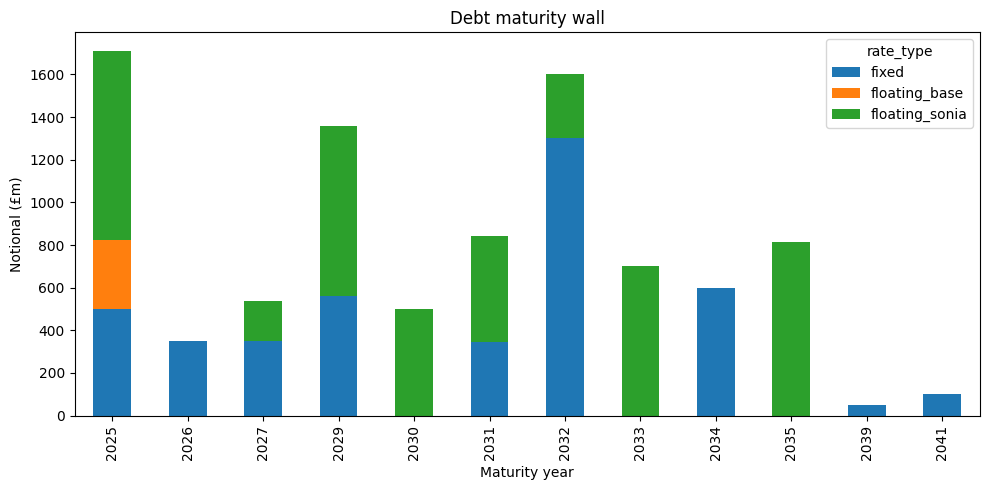

In [22]:
plot_maturity_wall(maturity_wall, output_path="outputs/maturity_wall.png")

In [23]:
years = np.arange(START_YEAR, START_YEAR + HORIZON_YEARS)

runoff_notional = []
for y in years:
    outstanding = debt.loc[debt["maturity_year"] >= y, "notional_gbp_m"].sum()
    runoff_notional.append(outstanding)

runoff_curve = pd.DataFrame({
    "year": years,
    "outstanding_gbp_m": runoff_notional
})

runoff_curve.head()

,year,outstanding_gbp_m
0,2025,9170
1,2026,7458
2,2027,7108
3,2028,6569
4,2029,6569


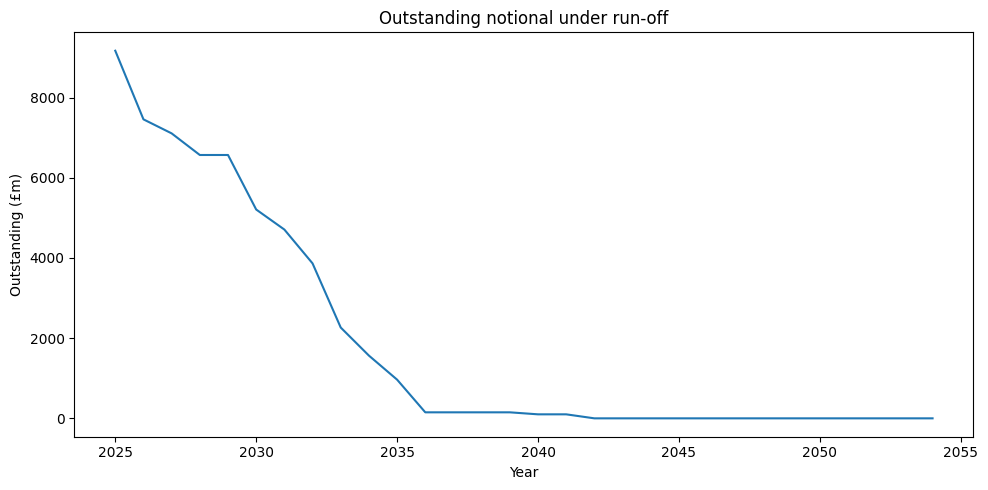

In [24]:
plot_runoff_outstanding(runoff_curve, output_path="outputs/runoff_outstanding.png")

In [25]:
scen = pd.read_csv(SCENARIO_PATH)
print(scen.head())
print(scen.columns.tolist())
print(scen.shape)

   scenario  year fiscal_year  sonia_rate  forward_rate  deviation  regime
0         0     0        FY26    0.040853      0.040853   0.000000  normal
1         0     1        FY27    0.000000      0.034313  -0.034313  crisis
2         0     2        FY28    0.019941      0.035024  -0.015083  normal
3         0     3        FY29    0.029093      0.037851  -0.008758  normal
4         0     4        FY30    0.034715      0.039965  -0.005250  normal
['scenario', 'year', 'fiscal_year', 'sonia_rate', 'forward_rate', 'deviation', 'regime']
(38000, 7)


In [26]:
rate_matrix = prepare_rate_matrix(
    scen_df=scen,
    scenario_col="scenario",
    year_col="year",
    rate_col="sonia_rate",
    horizon_years=HORIZON_YEARS
)

rate_matrix.head()

year,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
scenario,,,,,,,,,,,,,,,,,,,,,
0,0.040853,0.000000,0.019941,0.029093,0.034715,0.032598,0.031350,0.000000,0.004656,0.025410,...,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010
1,0.040853,0.037255,0.049277,0.054846,0.047426,0.055863,0.064062,0.023986,0.032941,0.044713,...,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555
2,0.040853,0.034987,0.038373,0.047471,0.043837,0.007504,0.050994,0.068577,0.076144,0.056751,...,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148
3,0.040853,0.033835,0.029307,0.034060,0.035046,0.037181,0.018378,0.012564,0.039419,0.043384,...,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003
4,0.040853,0.034960,0.035625,0.039207,0.043078,0.043494,0.048128,0.051474,0.071618,0.065942,...,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081


In [27]:
scen = pd.read_csv(SCENARIO_PATH)

print(scen.head())
print(scen.columns.tolist())
print(scen.shape)

# Optional QC
scen["reconstructed_rate"] = scen["forward_rate"] + scen["deviation"]
scen["check_diff"] = scen["sonia_rate"] - scen["reconstructed_rate"]
print("Max reconstruction error:", scen["check_diff"].abs().max())

# Core simulation input
rate_matrix = prepare_rate_matrix(
    scen_df=scen,
    scenario_col="scenario",
    year_col="year",
    rate_col="sonia_rate",
    horizon_years=HORIZON_YEARS
)

rate_matrix.head()

   scenario  year fiscal_year  sonia_rate  forward_rate  deviation  regime
0         0     0        FY26    0.040853      0.040853   0.000000  normal
1         0     1        FY27    0.000000      0.034313  -0.034313  crisis
2         0     2        FY28    0.019941      0.035024  -0.015083  normal
3         0     3        FY29    0.029093      0.037851  -0.008758  normal
4         0     4        FY30    0.034715      0.039965  -0.005250  normal
['scenario', 'year', 'fiscal_year', 'sonia_rate', 'forward_rate', 'deviation', 'regime']
(38000, 7)
Max reconstruction error: 1.3877787807814457e-17


year,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
scenario,,,,,,,,,,,,,,,,,,,,,
0,0.040853,0.000000,0.019941,0.029093,0.034715,0.032598,0.031350,0.000000,0.004656,0.025410,...,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010,0.039010
1,0.040853,0.037255,0.049277,0.054846,0.047426,0.055863,0.064062,0.023986,0.032941,0.044713,...,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555,0.044555
2,0.040853,0.034987,0.038373,0.047471,0.043837,0.007504,0.050994,0.068577,0.076144,0.056751,...,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148,0.051148
3,0.040853,0.033835,0.029307,0.034060,0.035046,0.037181,0.018378,0.012564,0.039419,0.043384,...,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003,0.052003
4,0.040853,0.034960,0.035625,0.039207,0.043078,0.043494,0.048128,0.051474,0.071618,0.065942,...,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081,0.060081


In [28]:
runoff_interest, runoff_outstanding = simulate_runoff(
    debt_df=debt,
    rate_matrix=rate_matrix,
    start_year=START_YEAR,
    horizon_years=HORIZON_YEARS
)

refi_interest, refi_outstanding = simulate_full_refinancing(
    debt_df=debt,
    rate_matrix=rate_matrix,
    start_year=START_YEAR,
    horizon_years=HORIZON_YEARS,
    refi_term=20
)

In [29]:
runoff_stats = summarise_distribution(runoff_interest, years)
refi_stats = summarise_distribution(refi_interest, years)

runoff_cum = cumulative_summary(runoff_interest)
refi_cum = cumulative_summary(refi_interest)

runoff_stats.head(), refi_stats.head(), runoff_cum, refi_cum

(   year        mean          p5         p50         p95
 0  2025  444.425731  444.425731  444.425731  444.425731
 1  2026  337.369204  308.580003  334.636072  400.586045
 2  2027  323.113716  239.050388  320.382263  398.827665
 3  2028  311.468937  197.444663  309.001033  390.561578
 4  2029  320.482710  193.401828  319.291130  407.060619,
    year        mean          p5         p50         p95
 0  2025  444.425731  444.425731  444.425731  444.425731
 1  2026  407.309540  378.520339  404.576408  470.526381
 2  2027  405.011032  315.050613  402.264913  485.752504
 3  2028  412.673426  292.380959  410.256460  502.602421
 4  2029  421.687199  289.987853  420.288851  514.072262,
 {'mean': np.float64(2787.9180387),
  'p5': np.float64(2327.9479644999997),
  'p50': np.float64(2790.6433685),
  'p95': np.float64(3165.9580857500005)},
 {'mean': np.float64(12833.354159233499),
  'p5': np.float64(9084.39078025),
  'p50': np.float64(12933.108742),
  'p95': np.float64(16051.23326795)})

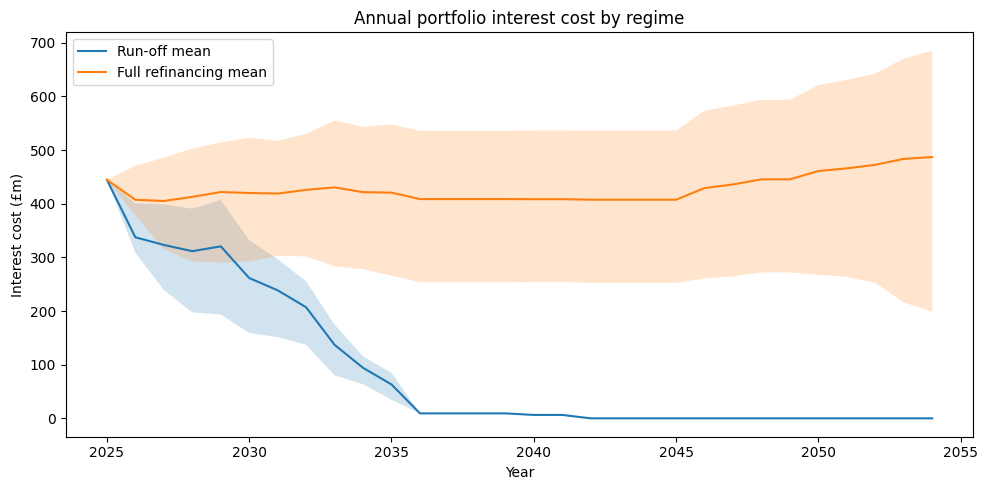

In [30]:
plot_interest_regimes(
    runoff_stats,
    refi_stats,
    output_path="outputs/interest_regimes.png"
)

In [31]:
high_risk_runoff = riskiest_years(runoff_stats, n=5)
high_risk_refi = riskiest_years(refi_stats, n=5)

print("Run-off")
display(high_risk_runoff)

print("Full refinancing")
display(high_risk_refi)

Run-off


,year,mean,p5,p50,p95,width_p95_p5
4,2029,320.482710,193.401828,319.291130,407.060619,213.658791
3,2028,311.468937,197.444663,309.001033,390.561578,193.116915
5,2030,261.450208,159.152831,260.926200,331.985104,172.832274
2,2027,323.113716,239.050388,320.382263,398.827665,159.777277
6,2031,238.599782,151.219574,239.428597,296.830990,145.611416


Full refinancing


,year,mean,p5,p50,p95,width_p95_p5
29,2054,486.889952,198.879168,499.096428,685.018178,486.139010
28,2053,483.448871,216.047394,495.540390,670.397300,454.349907
27,2052,472.378251,252.480252,482.600962,642.492138,390.011886
26,2051,465.813352,263.529407,475.357341,630.571722,367.042315
25,2050,460.848028,267.439975,470.119905,621.053256,353.613282


In [32]:
with pd.ExcelWriter("outputs/summary_tables.xlsx") as writer:
    debt.to_excel(writer, sheet_name="debt_stack", index=False)
    maturity_wall.to_excel(writer, sheet_name="maturity_wall")
    runoff_stats.to_excel(writer, sheet_name="runoff_interest", index=False)
    refi_stats.to_excel(writer, sheet_name="refi_interest", index=False)
    pd.DataFrame([runoff_cum]).to_excel(writer, sheet_name="runoff_cumulative", index=False)
    pd.DataFrame([refi_cum]).to_excel(writer, sheet_name="refi_cumulative", index=False)

print("Done")

Done
